In [1]:
import torch
import torch.nn.functional as F
import random
from torchjpeg import dct

def dct_transform(x, chs_remove=None, chs_pad=False):
    assert x.shape[1] == 3
    size = random.choice([8]); stride = size; pad = 0; dilation = 1; ratio = size

    x = x * 0.5 + 0.5

    # up-sample
    x = F.interpolate(x, scale_factor=ratio, mode='bilinear', align_corners=True)

    # convert to the YCbCr color domain, required by DCT
    x = x * 255
    x = dct.to_ycbcr(x)
    x = x - 128

    # perform block discrete cosine transform (BDCT)
    b, c, h, w = x.shape
    n_block = h // stride
    x = x.view(b * c, 1, h, w)
    x = F.unfold(x, kernel_size=(size, size), dilation=dilation, padding=pad, stride=(stride, stride))
    x = x.transpose(1, 2)
    x = x.view(b, c, -1, size, size)
    x_freq = dct.block_dct(x)
    x_freq = x_freq.view(b, c, n_block, n_block, size * size).permute(0, 1, 4, 2, 3)
    chs_remove = list(range(2)) 
    channels = list(set([i for i in range(x_freq.shape[2])]) - set(chs_remove)) 
    # channels = random.sample(channels, random.randint(min(1, len(channels)), len(channels)))
    x_freq = x_freq[:, :, channels, :, :]

    x_freq = x_freq.reshape(b, -1, n_block, n_block)
    x_freq = x_freq.mean(dim=1, keepdim=True).repeat(1,3,1,1) # mean at last

    # noise = torch.randn_like(x_freq) * x_freq.std() * 0.1
    # x_freq = x_freq + noise
    return x_freq

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import sys
import torch
sys.path.insert(0, "../../")
from minusface import MinusBackbone

conversion_model = MinusBackbone(mode='stage1')
conversion_model.load_state_dict(torch.load("../../checkpoints/minusface_stage1.pth", map_location='cpu'))
conversion_model = conversion_model.eval().to("cuda")


In [3]:
import numpy as np
from PIL import Image
def convert_batch(conv_raw):
    conv_raw = conv_raw.to("cuda")
    with torch.no_grad():
        out = conversion_model(conv_raw)[5]

    imgs = out.float()
    minv = imgs.amin(dim=(1, 2, 3), keepdim=True)
    maxv = imgs.amax(dim=(1, 2, 3), keepdim=True)
    imgs = (imgs - minv) / (maxv - minv + 1e-6) * 255
    imgs = dct_transform(imgs)
    print(imgs.shape)
    minv = imgs.amin(dim=(1, 2, 3), keepdim=True)
    maxv = imgs.amax(dim=(1, 2, 3), keepdim=True)
    imgs = (imgs - minv) / (maxv - minv + 1e-6) * 255
    Image.fromarray((imgs[0].permute(1,2,0).cpu().numpy() * 255).astype("uint8")).save("debug_minus.png")
    imgs = torch.tensor(np.array(imgs.cpu().detach()))

    return imgs

In [4]:
from torchvision import transforms
tf_conv = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])


In [5]:
import numpy as np
from PIL import Image

template = convert_batch(tf_conv(Image.open("0001.png").convert("RGB")).unsqueeze(0))

torch.Size([1, 3, 112, 112])


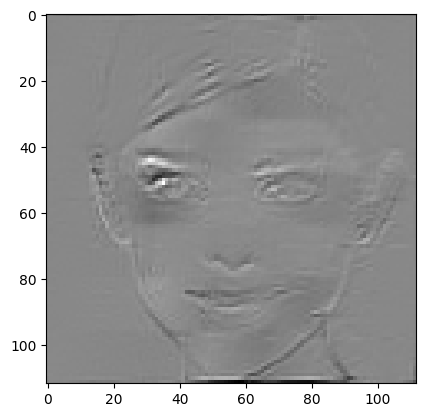

In [6]:
import pylab
pylab.imshow(template.cpu().numpy()[0].transpose(1, 2, 0)/255, cmap='gray')   

In [7]:
import torch
from onnx2torch import convert

onnx_model_path = "../../checkpoints/model.onnx"

student = convert(onnx_model_path)

In [8]:
student = torch.nn.Sequential(
    student,
).to("cuda:2")

In [9]:
student.load_state_dict(torch.load("student.pth.bak", map_location='cpu'))

<All keys matched successfully>

In [ ]:
student = student.eval()
pred = student(template.to("cuda:2")/255) 
template.max(), template.to("cuda:2").max()


In [ ]:
template.max(), template.to("cuda:2").max()

(tensor(255.), tensor(255., device='cuda:2'))

In [39]:
template.max(), template.max().dtype

(tensor(255.), torch.float32)

In [40]:
a = torch.clone(template).to("cuda:2")

In [44]:
# print(template.device)
# print(template[:5])
# print(template.to("cuda:2")[:5])

In [ ]:
from insightface.app import FaceAnalysis
import cv2
app = FaceAnalysis()
app.prepare(ctx_id=0, det_size=(160, 160))
def get_embedding(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (160,160))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    face = faces[0]
    embedding = face.embedding
    return embedding    


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [ ]:
import numpy as np
from insightface.app import FaceAnalysis
app = FaceAnalysis(name='antelopev2', root='../', providers=['CPUExecutionProvider'])

In [ ]:
def cosine_similarity(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return np.dot(a, b)

In [ ]:
cosine_similarity(get_embedding("0001.png"), pred[0].cpu().detach().numpy())


-0.02833867